In [1]:
%pip install numpy pandas optuna scikit-learn kagglehub matplotlib seaborn catboost wandb python-dotenv nbformat


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import wandb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from dotenv import load_dotenv
from features import preprocess, CAT_FEATURES

load_dotenv()

True

In [3]:
RANDOM_SEED = 42
CV_FOLDS = 5

In [4]:
df = pd.read_csv('data/train.csv')

In [5]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
df.shape

(8693, 14)

In [7]:
df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

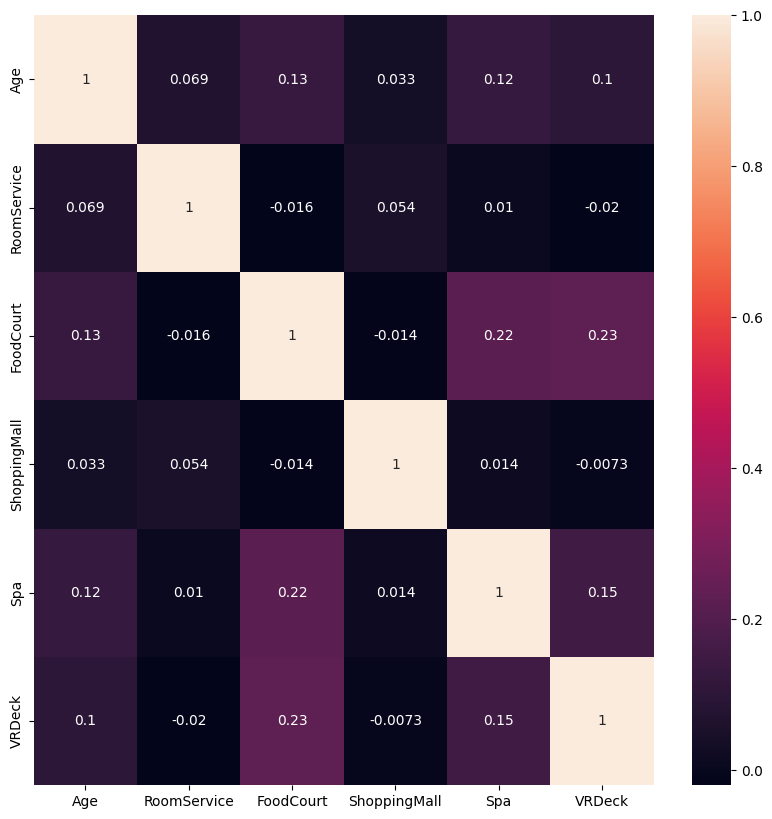

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)
plt.show()

# Baseline Model

In [9]:
X, y = preprocess(df, is_train=True)
print(X.shape, y.shape)

(8693, 25) (8693,)


In [10]:
wandb.init(
    project="spaceship-titanic",
    config={
        "model": "catboost",
        "iterations": 3000,
        "learning_rate": 0.01,
        "depth": 5,
        "cv_folds": CV_FOLDS,
    }
)

config = wandb.config

kf = StratifiedKFold(n_splits=config.cv_folds, shuffle=True, random_state=RANDOM_SEED)
scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=config.iterations,
        learning_rate=config.learning_rate,
        depth=config.depth,
        cat_features=CAT_FEATURES,
        verbose=0,
    )
    model.fit(X_train, y_train)

    acc = accuracy_score(y_val, model.predict(X_val))
    scores.append(acc)
    print(f"Fold {fold + 1}: {acc:.4f}")

wandb.log({"cv_mean": np.mean(scores), "cv_std": np.std(scores)})
wandb.finish()
print(f"\nCV mean: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: agakinalexandr (agakinalexandr-singidunum-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fold 1: 0.8005
Fold 2: 0.7895
Fold 3: 0.8091
Fold 4: 0.8061
Fold 5: 0.7917


cv_mean,▁
cv_std,▁
cv_mean,0.79938
cv_std,0.0077



CV mean: 0.7994 ± 0.0077


# Submission

In [12]:
test_df = pd.read_csv('data/test.csv')
X_test, passenger_ids = preprocess(test_df, is_train=False)

preds = model.predict(X_test).astype(bool)

submission = pd.DataFrame({"PassengerId": passenger_ids, "Transported": preds})
submission.to_csv('submission.csv', index=False)
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
